# ESc1 signal EDA

Compact diagnostics for the 5-minute take-home data. Tests here are descriptive screens; ordinary correlation and Ljung–Box p-values do not fully account for market-time dependence.

Large cross-sectional calculations use a bounded sample so the notebook remains interactive. Structural-break summaries use the full history.

In [1]:
from pathlib import Path
import os, re, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy.cluster.hierarchy import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "takehome").exists())
sys.path.insert(0, str(ROOT / "src"))
from takehome.eda import (
    acf_matrix, autocorrelation_table, bell_shape_table, correlation_clustering,
    correlation_to_column, infer_feature_cols, monthly_shift_scores, redundant_pairs,
)

DATA_PATH = Path(os.environ.get("DATA_PATH", ROOT / "ESc1_signal_components_5min (6).parquet"))
CROSS_SECTION_N, ACF_N = 50_000, 100_000
SCATTER_N_FEATURES, SCATTER_N_ROWS = 12, 2_000
ACF_LAG, SEASONAL_NLAGS = 15, 288

## Load and identify columns

In [2]:
if DATA_PATH.suffix.lower() == ".parquet":
    df = pd.read_parquet(DATA_PATH)
elif DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    raise ValueError(f"Unsupported file: {DATA_PATH}")

if df.index.name and re.search(r"time|timestamp|date|(^|_)ts($|_)", str(df.index.name), re.I):
    df = df.reset_index()

feature_cols = infer_feature_cols(df)
price_col = "adjMid"
cashflow_col = next((c for c in df.columns if "cashflow" in c.lower()), None)
time_col = next((c for c in df.columns if re.search(r"(^|_)(time|timestamp|date|ts)($|_)", c, re.I)), None)
df["_ret1"] = df[price_col].pct_change(fill_method=None)

print(f"shape={df.shape}")
print(f"features={len(feature_cols)}")
print(f"price={price_col!r}, cashflow={cashflow_col!r}, time={time_col!r}")
display(df.head())

idx = np.linspace(0, len(df) - 1, min(CROSS_SECTION_N, len(df)), dtype=int)
xs = df.iloc[idx].copy()
acf_source = df.iloc[:min(ACF_N, len(df))].copy()

shape=(951552, 107)
features=99
price='adjMid', cashflow='cashflow', time='trade_date'


,msgStamp,trade_date,wmid,adjMid,volume,cashflow,ret_5m,x1,x2,x3,...,x91,x92,x93,x94,x95,x96,x97,x98,x99,_ret1
0,2013-12-31 18:00:00-05:00,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-12-31 18:05:00-05:00,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-12-31 18:10:00-05:00,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-12-31 18:15:00-05:00,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-12-31 18:20:00-05:00,2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Scatter matrix

A 99×99 scatter matrix is 9,801 panels and is not interpretable. Plot a deterministic representative subset; the full relationship structure is covered by the all-feature clustered correlation matrix below.

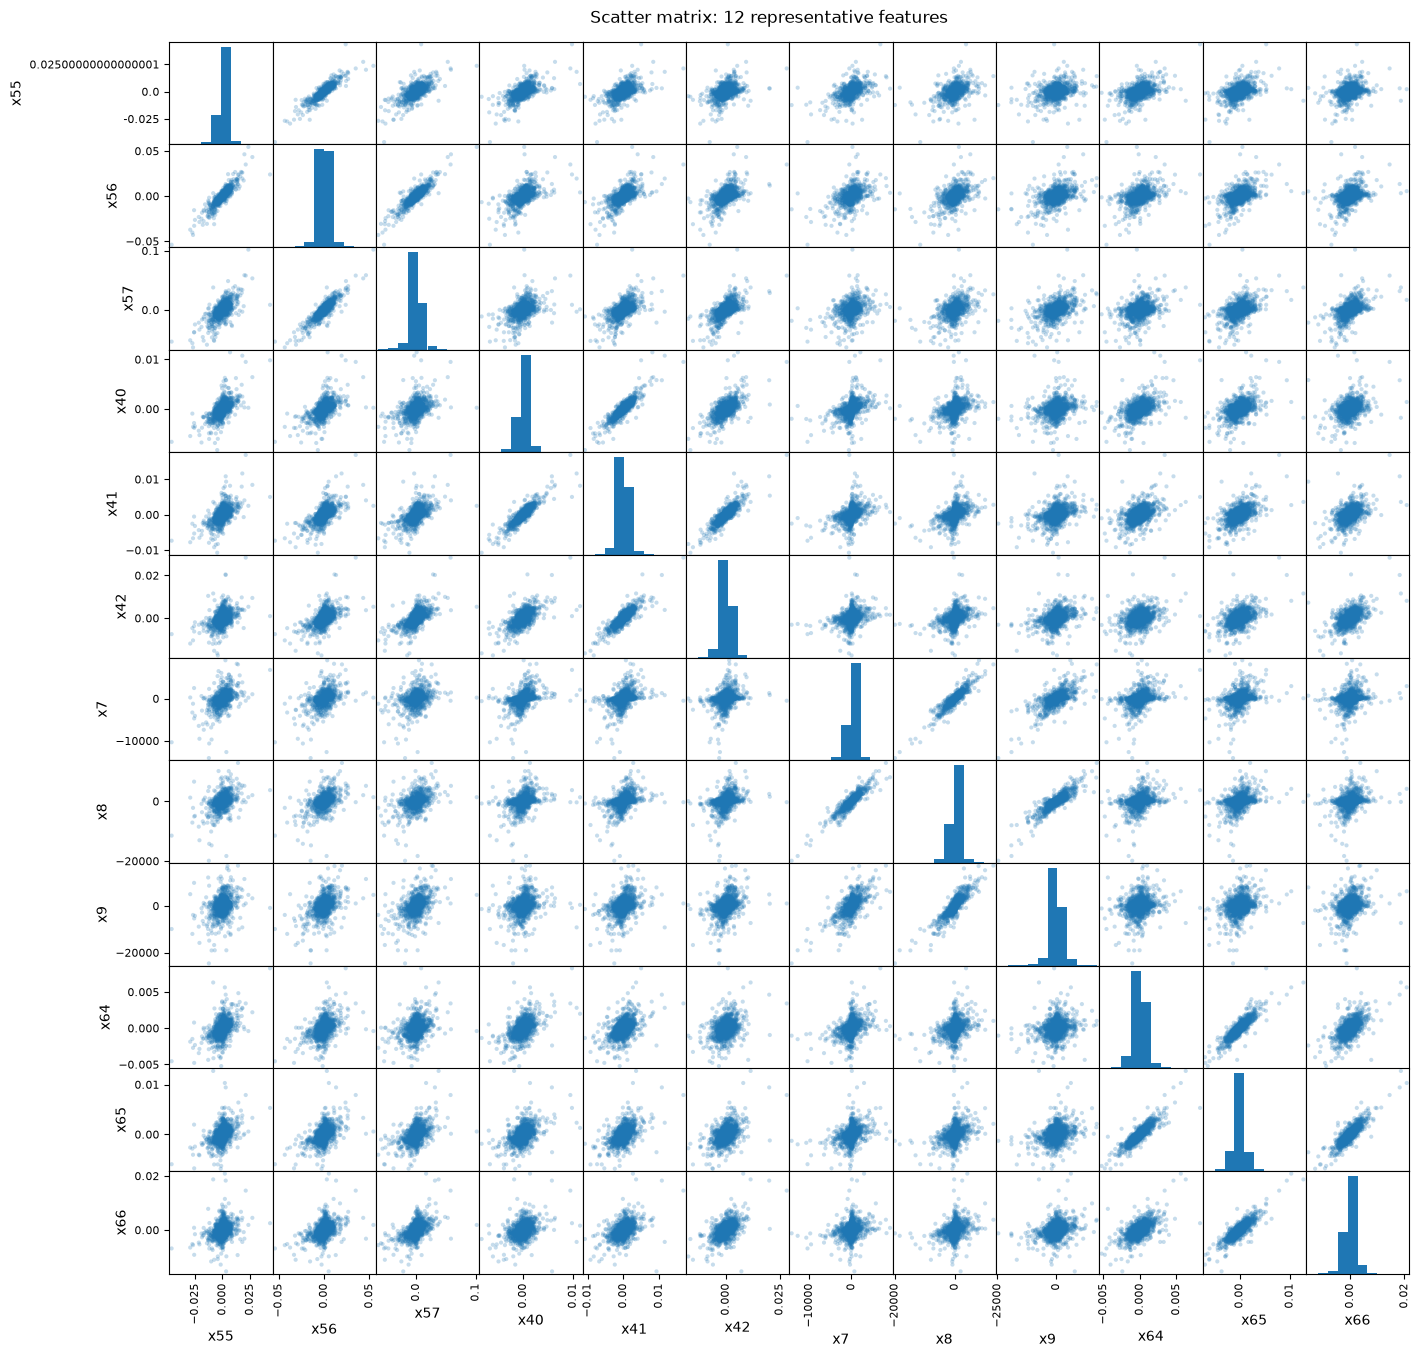

In [3]:
scatter_features = sorted(feature_cols, key=lambda c: xs[c].notna().sum(), reverse=True)[:SCATTER_N_FEATURES]
clean = xs[scatter_features].dropna()
plot_df = clean.sample(min(SCATTER_N_ROWS, len(clean)), random_state=0)
scatter_matrix(plot_df, figsize=(16, 16), diagonal="hist", alpha=0.25)
plt.suptitle(f"Scatter matrix: {len(scatter_features)} representative features", y=0.9)
plt.show()

## 2. Distribution-shape screen + return sanity check

I do **not** test Gaussianity. For feature engineering I only want to flag distributions that are clearly awkward: multimodal, strongly asymmetric, or dominated by a small set of repeated values.

The compact screen combines:
- **Hartigan's dip test** for unimodality;
- **Bowley skew** (quartile-based, robust to heavy tails);
- exact point-mass / discreteness checks.

Kurtosis is intentionally ignored, so a symmetric, centered, sharply peaked heavy-tailed distribution can still pass.

The return check uses exactly `adjMid.pct_change()` as a sanity check that the anonymized features contain real market information. It is not the eventual forward-return target.

,feature,n,nunique,max_mass,robust_skew,dip_pvalue,bell_like


Bell-like: 99/99; flagged: 0


,feature,pearson,pearson_p,spearman,spearman_p,n,pearson_q,spearman_q,max_abs_corr
57,x58,-0.439437,0.000000e+00,-0.350811,0.000000e+00,22259,0.000000e+00,0.000000e+00,0.439437
60,x61,0.433542,0.000000e+00,0.364571,0.000000e+00,11096,0.000000e+00,0.000000e+00,0.433542
42,x43,0.397730,0.000000e+00,0.326407,9.441505e-274,11096,0.000000e+00,1.335299e-272,0.397730
45,x46,0.370479,8.808007e-241,0.286996,4.728695e-141,7440,5.449955e-240,2.925880e-140,0.370479
36,x37,0.366845,0.000000e+00,0.305361,6.356576e-238,11086,0.000000e+00,7.866263e-237,0.366845
33,x34,0.354741,5.954965e-313,0.286156,1.426291e-199,10636,5.895415e-312,1.283662e-198,0.354741
18,x19,0.329614,5.177224e-272,0.272236,8.209029e-183,10799,4.659502e-271,5.804956e-182,0.329614
54,x55,0.327622,0.000000e+00,0.263399,0.000000e+00,31857,0.000000e+00,0.000000e+00,0.327622
21,x22,0.320900,8.926563e-252,0.232823,4.030229e-130,10572,6.312355e-251,2.347016e-129,0.320900
30,x31,0.316850,5.454866e-253,0.260320,1.678040e-168,10912,4.154090e-252,1.107506e-167,0.316850


Features with |Pearson or Spearman corr| >= 0.10: 45


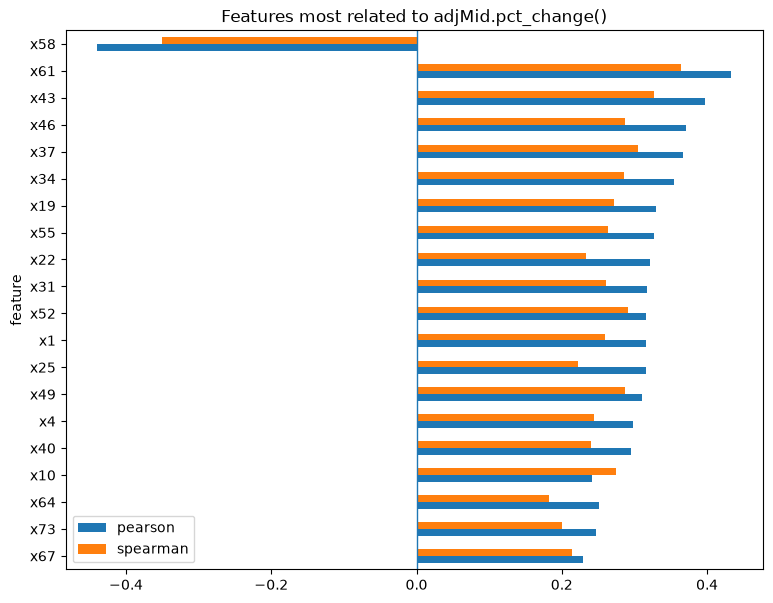

In [4]:
shape = bell_shape_table(xs, feature_cols)
flagged_shape = shape.loc[~shape.bell_like]
display(flagged_shape.head(30))
print(f"Bell-like: {shape.bell_like.sum()}/{len(shape)}; flagged: {len(flagged_shape)}")

if len(flagged_shape):
    cols = flagged_shape.feature.head(12)
    fig, axes = plt.subplots(3, 4, figsize=(14, 9))
    for ax, col in zip(axes.flat, cols):
        sns.histplot(xs[col].dropna(), bins=80, stat="density", ax=ax)
        ax.set_title(col)
    for ax in axes.flat[len(cols):]:
        ax.axis("off")
    fig.suptitle("Flagged feature distributions", y=1.01)
    plt.tight_layout()
    plt.show()

return_corr = correlation_to_column(xs, "_ret1", feature_cols)
strong_target = return_corr.loc[return_corr.max_abs_corr >= 0.10]
display(strong_target)
print(f"Features with |Pearson or Spearman corr| >= 0.10: {len(strong_target)}")

ax = return_corr.head(20).sort_values("max_abs_corr").plot.barh(
    x="feature", y=["pearson", "spearman"], figsize=(9, 7),
    title="Features most related to adjMid.pct_change()")
ax.axvline(0, linewidth=1)
plt.show()

## 3. Feature correlation and dendrogram

Cluster using distance $1-|\rho_S|$ so strongly positive and strongly negative variants are grouped together. The heatmap retains signed Spearman correlation.

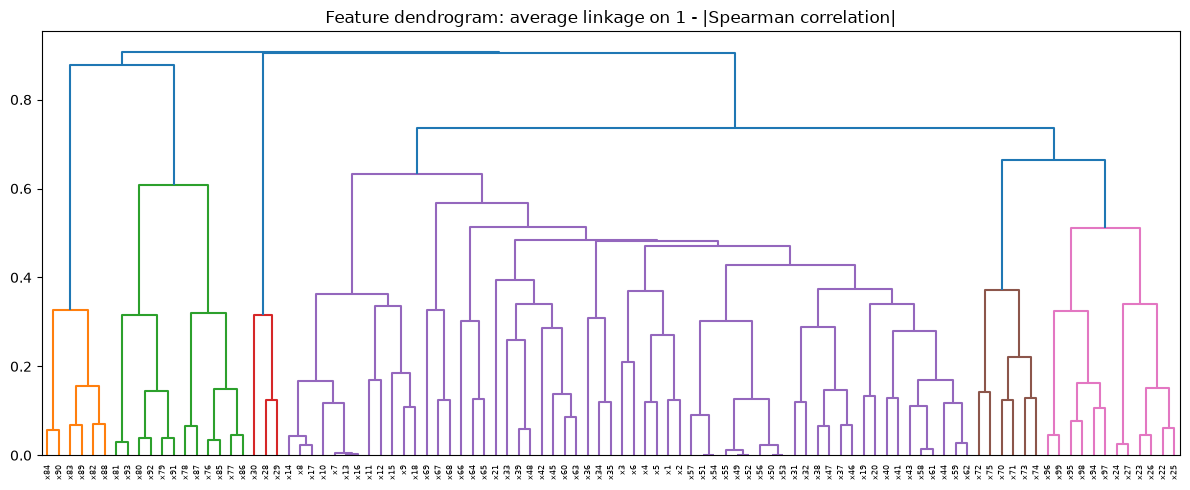

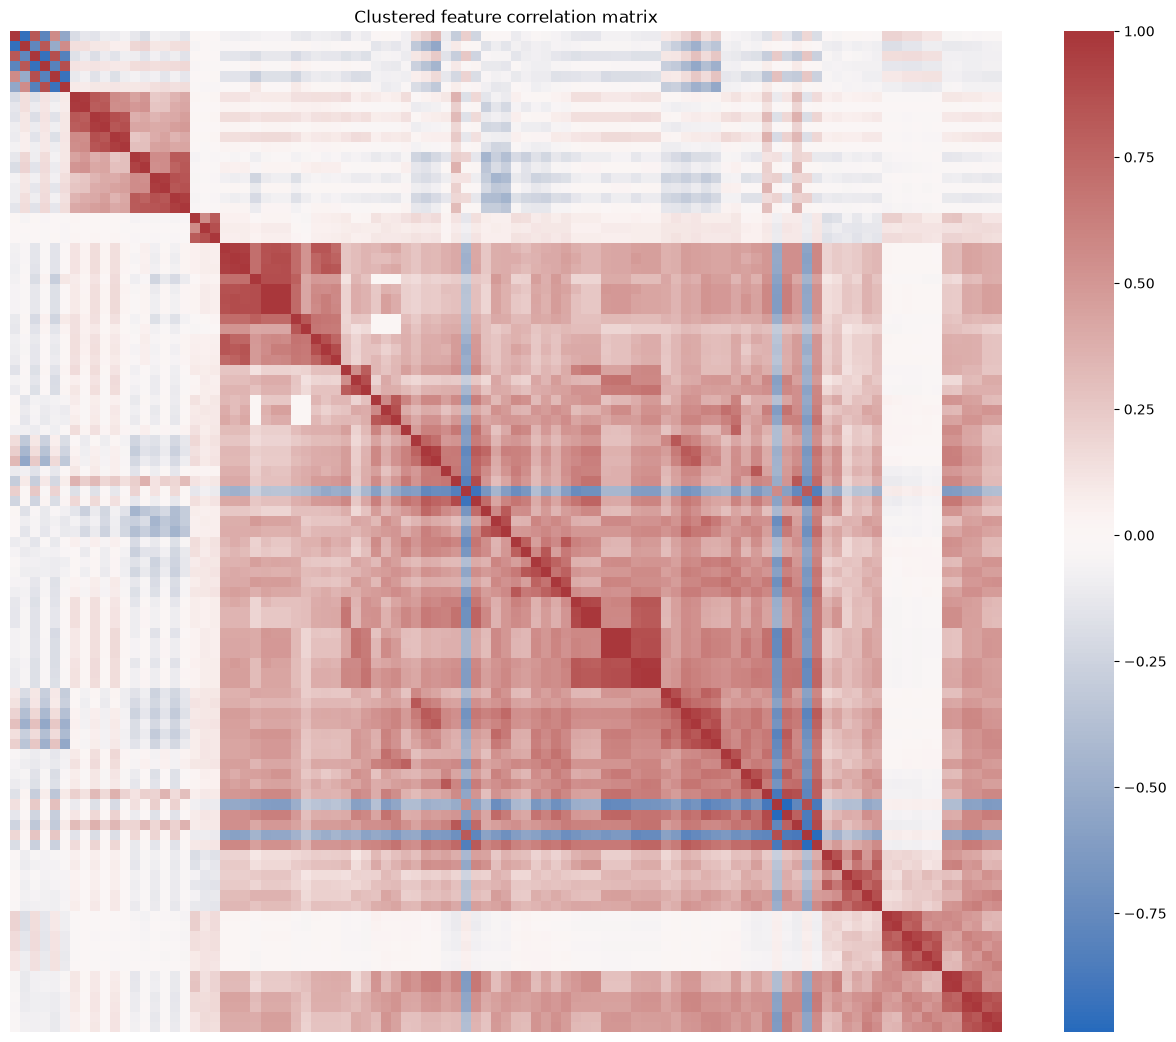

,feature1,feature2,corr,abs_corr,index_gap
0,x49,x52,0.999996,0.999996,3
1,x50,x53,0.999878,0.999878,3
2,x51,x54,0.999661,0.999661,3
3,x13,x16,0.997614,0.997614,3
4,x7,x16,0.995231,0.995231,9
5,x7,x13,0.994403,0.994403,6
6,x52,x55,0.988286,0.988286,3
7,x49,x55,0.988280,0.988280,6
8,x58,x61,-0.985391,0.985391,3
9,x8,x17,0.976219,0.976219,9


,n_pairs,median_abs_corr,p90_abs_corr,frac_gt_080
index_gap,,,,
1,98,0.821126,0.875433,0.632653
3,96,0.623933,0.954264,0.229167
2,97,0.562998,0.778475,0.082474
6,93,0.514302,0.855237,0.107527
12,87,0.474641,0.705380,0.034483
15,84,0.460887,0.704984,0.035714
9,90,0.453923,0.773047,0.100000
30,69,0.453082,0.585713,0.000000
18,81,0.439594,0.682485,0.037037


,count,mean,median
same_mod3,,,
False,3267,0.280797,0.270351
True,1584,0.339459,0.354429


Strong pairs with index gap divisible by 3: 36.2%


In [5]:
corr, z, order = correlation_clustering(xs, feature_cols, method="spearman")

plt.figure(figsize=(max(12, len(feature_cols) * 0.12), 5))
dendrogram(z, labels=feature_cols, leaf_rotation=90, leaf_font_size=6)
plt.title("Feature dendrogram: average linkage on 1 - |Spearman correlation|")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 13))
sns.heatmap(corr.loc[order, order], center=0, cmap="vlag", xticklabels=False, yticklabels=False)
plt.title("Clustered feature correlation matrix")
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs = redundant_pairs(corr, threshold=0.80)
display(pairs.head(30))

gap_pairs = pairs.dropna(subset=["index_gap"]).copy()
gap_pairs["index_gap"] = gap_pairs.index_gap.astype(int)

all_pairs = redundant_pairs(corr, threshold=0.0).dropna(subset=["index_gap"])
all_pairs["index_gap"] = all_pairs.index_gap.astype(int)
gap_summary = (
    all_pairs.groupby("index_gap")
    .agg(
        n_pairs=("abs_corr", "size"),
        median_abs_corr=("abs_corr", "median"),
        p90_abs_corr=("abs_corr", lambda x: x.quantile(.9)),
        frac_gt_080=("abs_corr", lambda x: (x >= .8).mean()),
    )
    .sort_values("median_abs_corr", ascending=False)
)
display(gap_summary.head(20))

all_pairs["same_mod3"] = all_pairs.index_gap.mod(3).eq(0)
mod3_summary = all_pairs.groupby("same_mod3").abs_corr.agg(["count", "mean", "median"])
display(mod3_summary)
print(f"Strong pairs with index gap divisible by 3: {(gap_pairs.index_gap.mod(3).eq(0)).mean():.1%}")

## 4. Autocorrelation

For a raw feature series, a lag-15 **Ljung–Box** test directly asks whether serial correlation remains. Breusch–Godfrey is designed for regression residuals, so fitting a dummy regression just to manufacture residuals adds machinery without changing the question.

,feature,n,acf1,max_abs_acf_1_to_lag,lb_stat,lb_pvalue,lb_qvalue
41,x42,63781,0.989611,0.989611,620898.956567,0.0,0.0
77,x78,52345,0.990763,0.990763,524855.594948,0.0,0.0
5,x6,51236,0.990771,0.990771,515978.594116,0.0,0.0
59,x60,52378,0.989412,0.989412,508789.181157,0.0,0.0
56,x57,55113,0.987388,0.987388,507645.072551,0.0,0.0
2,x3,51342,0.990555,0.990555,500331.362047,0.0,0.0
65,x66,49188,0.986500,0.986500,462353.084027,0.0,0.0
92,x93,36414,0.990948,0.990948,371081.781735,0.0,0.0
86,x87,36416,0.990749,0.990749,369536.513814,0.0,0.0
80,x81,36414,0.990457,0.990457,366494.954994,0.0,0.0


Ljung-Box lag 15, FDR q<5%: 75.8%


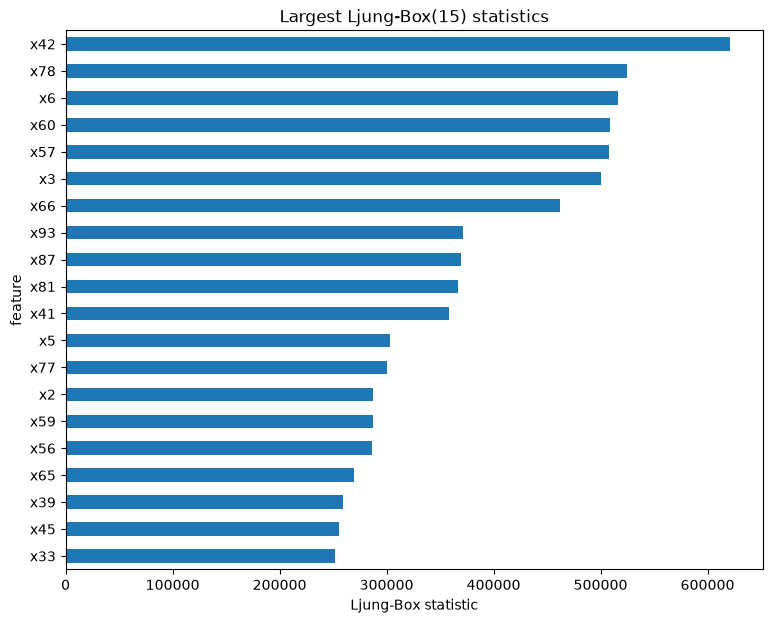

In [6]:
auto = autocorrelation_table(acf_source, feature_cols, lag=ACF_LAG)
display(auto.head(20))
print(f"Ljung-Box lag {ACF_LAG}, FDR q<5%: {(auto.lb_qvalue < 0.05).mean():.1%}")

auto.head(20).sort_values("lb_stat").plot.barh(
    x="feature", y="lb_stat", figsize=(9, 7), legend=False,
    title=f"Largest Ljung-Box({ACF_LAG}) statistics")
plt.xlabel("Ljung-Box statistic")
plt.show()

### 4.1 Longer-lag / seasonal ACF patterns

Repeated bands or peaks in the heatmap flag periodic structure. These are **row lags**: if source bars have gaps, lag 288 is not automatically a 24-hour clock-time lag.

,peak_lag,peak_acf
x93,16,0.618140
x87,16,0.615451
x6,16,0.608857
x81,16,0.608561
x78,16,0.606511
x39,16,0.598052
x96,16,0.587787
x45,16,0.586951
x33,16,0.585128
x60,16,0.583070


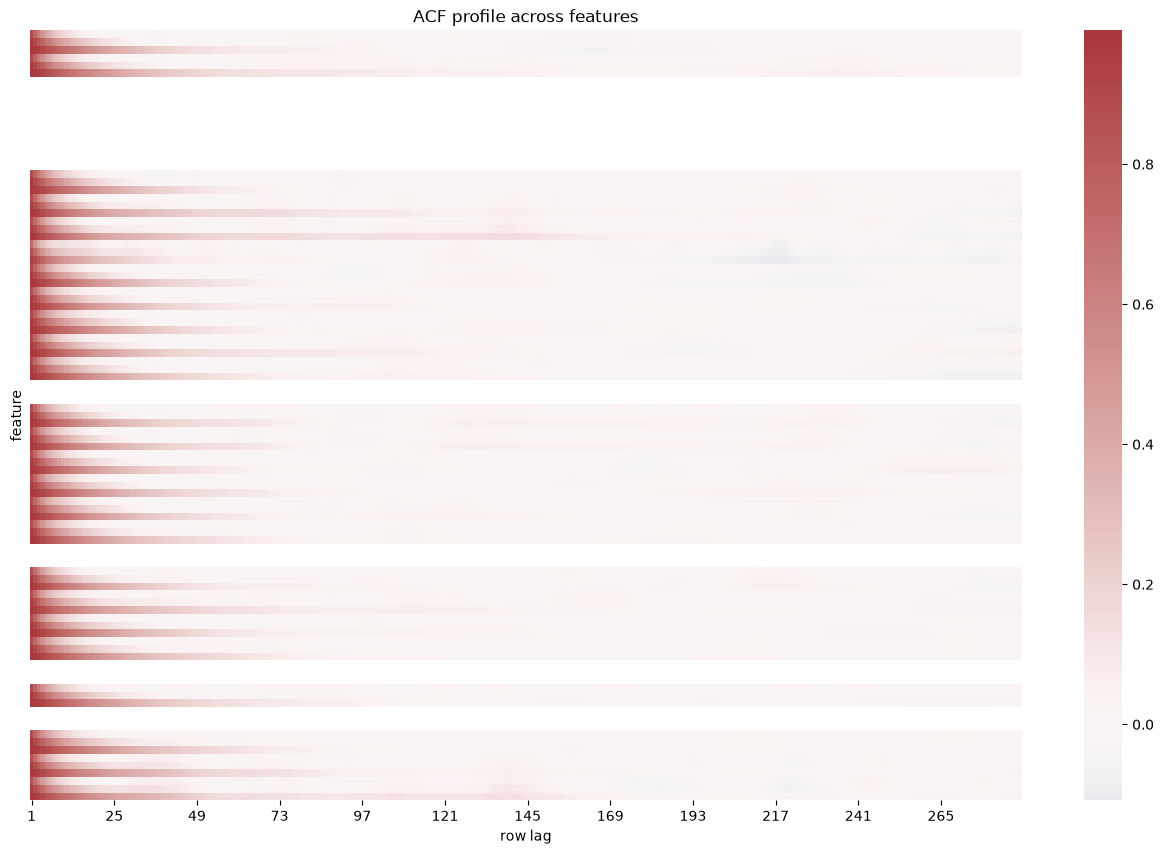

In [7]:
season_acf = acf_matrix(acf_source, feature_cols, nlags=SEASONAL_NLAGS)
long_lag = season_acf.loc[ACF_LAG + 1:]
valid = long_lag.columns[long_lag.notna().any()]
peak_lag = long_lag[valid].abs().idxmax()
peak = pd.DataFrame({
    "peak_lag": peak_lag,
    "peak_acf": [long_lag.loc[peak_lag[c], c] for c in valid],
}).sort_values("peak_acf", key=lambda s: s.abs(), ascending=False)
display(peak.head(20))

plt.figure(figsize=(16, 10))
sns.heatmap(season_acf.loc[1:].T, center=0, cmap="vlag", xticklabels=24, yticklabels=False)
plt.xlabel("row lag")
plt.ylabel("feature")
plt.title("ACF profile across features")
plt.show()

## 5. Simple time-varying structural-break screen

Avoid another dependency: compare adjacent calendar months.

- **mean shift z** = month-to-month mean change / full-sample feature standard deviation
- **log std ratio** = log(current-month std / previous-month std)

Large sustained values localize changes in level or scale. This is a diagnostic, not a formal break-date estimator.

,max_abs_monthly_mean_shift_z,max_abs_monthly_log_std_ratio
x67,7.245917,1.662707
x68,6.927042,1.861180
x69,5.961785,2.133450
x30,1.377850,2.899247
x27,1.326093,1.544659
x24,1.257790,1.561496
x29,1.130424,2.891253
x99,1.088042,1.652901
x33,1.022932,1.325685
x39,1.001554,1.167170


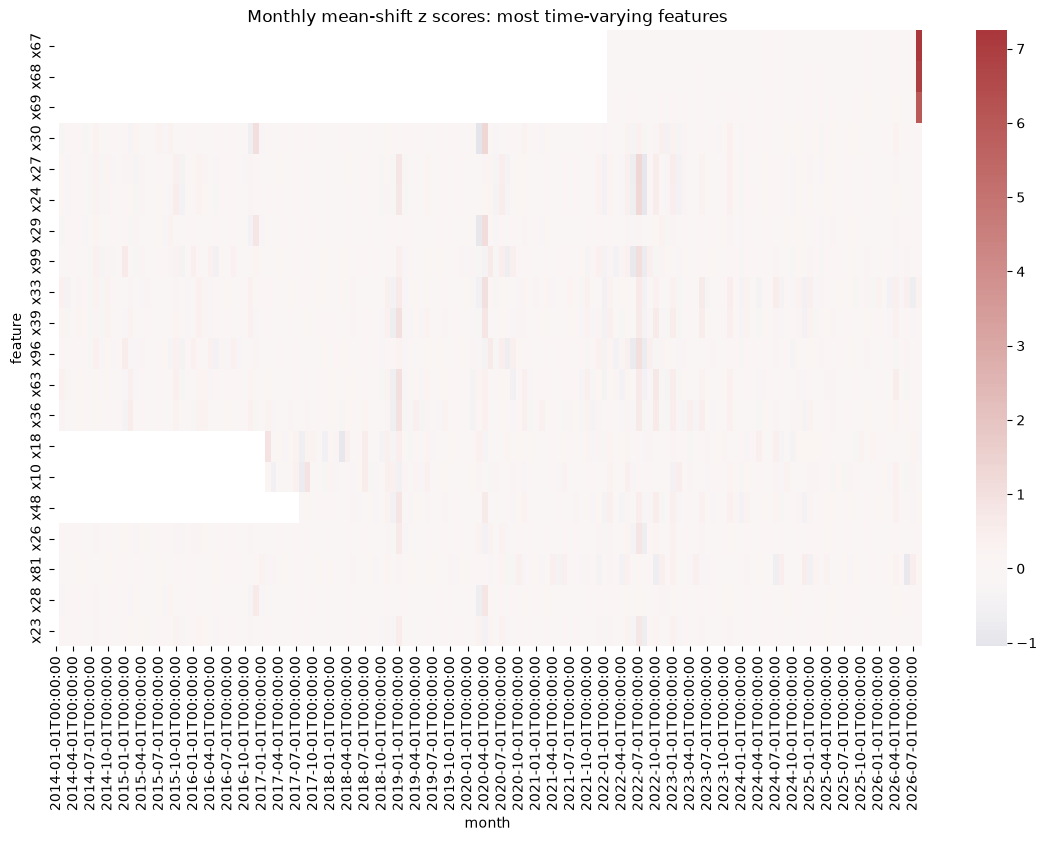

In [8]:
if time_col is None:
    print("No timestamp-like column found; set time_col manually.")
else:
    raw_t = df[time_col]
    if pd.api.types.is_numeric_dtype(raw_t):
        m = raw_t.dropna().abs().median()
        unit = "ns" if m > 1e17 else "us" if m > 1e14 else "ms" if m > 1e11 else "s"
        df = df.copy()
        df[time_col] = pd.to_datetime(raw_t, unit=unit)
    else:
        df = df.copy()
        df[time_col] = pd.to_datetime(raw_t)

    mean_shift, vol_shift = monthly_shift_scores(df, time_col, feature_cols)
    breaks = pd.DataFrame({
        "max_abs_monthly_mean_shift_z": mean_shift.abs().max(),
        "max_abs_monthly_log_std_ratio": vol_shift.abs().max(),
    }).sort_values("max_abs_monthly_mean_shift_z", ascending=False)
    display(breaks.head(20))

    unstable = breaks.head(20).index
    plt.figure(figsize=(14, 8))
    sns.heatmap(mean_shift[unstable].T, center=0, cmap="vlag")
    plt.title("Monthly mean-shift z scores: most time-varying features")
    plt.xlabel("month")
    plt.ylabel("feature")
    plt.show()

## 6. Cashflow and the named market variables

This section deliberately excludes the anonymized `x*` features. It shows how cashflow relates to the other interpretable numeric market fields (price, volume, etc.).

Named numeric variables: ['wmid', 'adjMid', 'volume', 'cashflow', 'ret_5m']


,wmid,adjMid,volume,cashflow,ret_5m
wmid,1.000000,0.999048,0.036590,0.012883,0.008165
adjMid,0.999048,1.000000,0.038398,0.012743,0.008042
volume,0.036590,0.038398,1.000000,0.001012,0.010041
cashflow,0.012883,0.012743,0.001012,1.000000,-0.023149
ret_5m,0.008165,0.008042,0.010041,-0.023149,1.000000


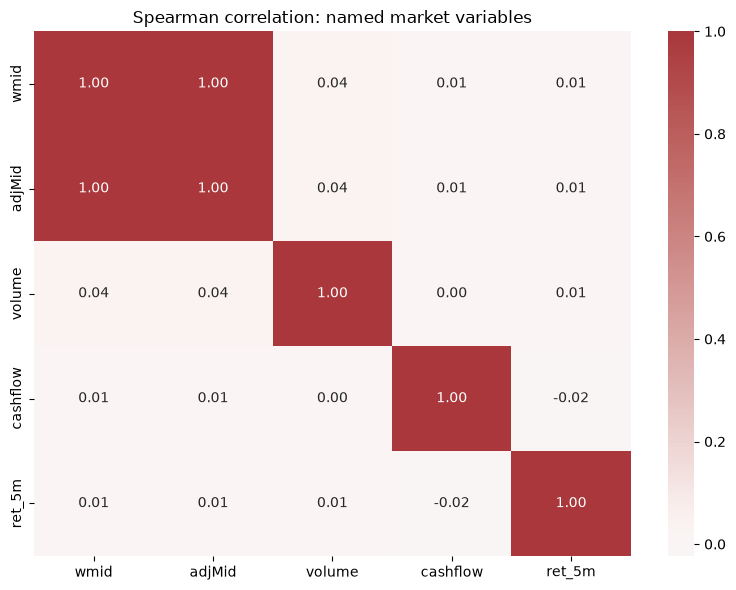

,spearman
ret_5m,-0.023149
wmid,0.012883
adjMid,0.012743
volume,0.001012


In [9]:
named_numeric = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in feature_cols and not c.startswith("_")
]
print("Named numeric variables:", named_numeric)

named_corr = xs[named_numeric].corr(method="spearman")
display(named_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(named_corr, annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Spearman correlation: named market variables")
plt.tight_layout()
plt.show()

if cashflow_col is not None and cashflow_col in named_corr:
    cash_named = (
        named_corr[cashflow_col]
        .drop(cashflow_col)
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("spearman")
        .to_frame()
    )
    display(cash_named)

## Compact EDA summary

In [10]:
print(f"shape={df.shape}, features={len(feature_cols)}, time={time_col!r}, cashflow={cashflow_col!r}")
print(f"Bell-like distributions: {shape.bell_like.sum()}/{len(shape)}")
print(f"Largest |same-bar return correlation|: {return_corr.max_abs_corr.max():.4f} ({return_corr.iloc[0].feature})")
print(f"Features with |target correlation| >= 0.10: {len(strong_target)}")
print(f"Largest |feature-feature Spearman|: {upper.abs().max():.4f}")
print(f"Strong feature pairs (|rho|>=0.80): {len(pairs)}")
print(f"Strong pairs with index gap divisible by 3: {(gap_pairs.index_gap.mod(3).eq(0)).mean():.1%}")
print(f"Largest LB({ACF_LAG}) statistic: {auto.lb_stat.max():.1f} ({auto.iloc[0].feature})")
print(f"Autocorrelated at LB({ACF_LAG}) after FDR: {(auto.lb_qvalue < 0.05).sum()}/{len(auto)}")
print(f"Seasonal/long-lag ACF available: {len(peak)}/{len(feature_cols)}")

print("\nFlagged distribution shapes")
print(flagged_shape.head(15).to_string(index=False))
print("\nTop return-feature sanity correlations")
print(return_corr[["feature", "pearson", "spearman", "max_abs_corr"]].head(15).to_string(index=False))
print("\nTop redundant feature pairs")
print(pairs.head(15).to_string(index=False))
print("\nAll-pair index-gap pattern")
print(gap_summary.head(15).to_string())
print("\nSame-mod-3 vs other pairs")
print(mod3_summary.to_string())
print("\nLargest Ljung-Box statistics")
print(auto[["feature", "acf1", "max_abs_acf_1_to_lag", "lb_stat", "lb_pvalue", "lb_qvalue"]].head(15).to_string(index=False))
if time_col is not None:
    print("\nLargest monthly distribution shifts")
    print(breaks.head(10).to_string())
if cashflow_col is not None and cashflow_col in named_corr:
    print("\nCashflow vs named variables")
    print(cash_named.to_string())
print("\nTop long-lag ACF peaks")
print(peak.head(10).to_string())

shape=(951552, 107), features=99, time='trade_date', cashflow='cashflow'
Bell-like distributions: 99/99
Largest |same-bar return correlation|: 0.4394 (x58)
Features with |target correlation| >= 0.10: 45
Largest |feature-feature Spearman|: 1.0000
Strong feature pairs (|rho|>=0.80): 152
Strong pairs with index gap divisible by 3: 36.2%
Largest LB(15) statistic: 620899.0 (x42)
Autocorrelated at LB(15) after FDR: 75/99
Seasonal/long-lag ACF available: 75/99

Flagged distribution shapes
Empty DataFrame
Columns: [feature, n, nunique, max_mass, robust_skew, dip_pvalue, bell_like]
Index: []

Top return-feature sanity correlations
feature   pearson  spearman  max_abs_corr
    x58 -0.439437 -0.350811      0.439437
    x61  0.433542  0.364571      0.433542
    x43  0.397730  0.326407      0.397730
    x46  0.370479  0.286996      0.370479
    x37  0.366845  0.305361      0.366845
    x34  0.354741  0.286156      0.354741
    x19  0.329614  0.272236      0.329614
    x55  0.327622  0.263399      0